# STEP 4. 기초 EDA

데이터가 분석 가능한 상태인지 확인합니다.

1. 상권유형 × 업종 교차 — 표본 충분성
2. 상권유형별 순감소율 — H2 배경
3. 자치구별 순감소율
4. 분포 확인 — 로그 변환 필요성
5. 공변량 상관 — 다중공선성 사전 점검

In [1]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [2]:
import matplotlib.pyplot as plt
from config import PROC, FIG, TARGET_TYPE, set_korean_font
set_korean_font()

d = pd.read_pickle(PROC / "03_panel.pkl")
print(f"표본 {d.shape} | 양성률 {d['y'].mean():.1%}")

표본 (59632, 36) | 양성률 26.6%


## 4-1. 상권유형 × 업종 표본 수

In [3]:
ct = pd.crosstab(d["서비스_업종_코드_명"], d["상권유형"])
display(ct)
print("※ 관광특구는 표본이 적어 별도 결론을 내지 않습니다.")

상권유형,골목상권,관광특구,발달상권,전통시장
서비스_업종_코드_명,,,,
분식전문점,3062,72,2239,1273
양식음식점,1378,72,2111,382
일식음식점,910,72,2087,357
제과점,1298,72,1770,236
중식음식점,1105,72,1837,349
치킨전문점,716,60,842,314
커피-음료,7060,72,2849,1054
패스트푸드점,712,72,1477,132
한식음식점,9776,72,2951,2643


※ 관광특구는 표본이 적어 별도 결론을 내지 않습니다.


## 4-2. 상권유형별 순감소율

In [4]:
t = d.groupby("상권유형")["y"].agg(칸수="size", 순감소율="mean").sort_values("순감소율")
display(t.round(3))

,칸수,순감소율
상권유형,,
전통시장,7953,0.233
골목상권,30367,0.244
발달상권,20616,0.306
관광특구,696,0.378


## 4-3. 자치구별 순감소율 (골목상권)

In [5]:
gm = d[d["상권유형"] == TARGET_TYPE]
gu = (gm.groupby("자치구")["y"].agg(칸수="size", 순감소율="mean")
      .sort_values("순감소율", ascending=False))
display(gu.round(3))

,칸수,순감소율
자치구,,
도봉구,932,0.277
관악구,1592,0.276
강서구,1623,0.273
중랑구,1402,0.266
강동구,1456,0.263
강북구,963,0.261
구로구,1211,0.260
성동구,1091,0.255
마포구,1970,0.251


## 4-4. 시각화

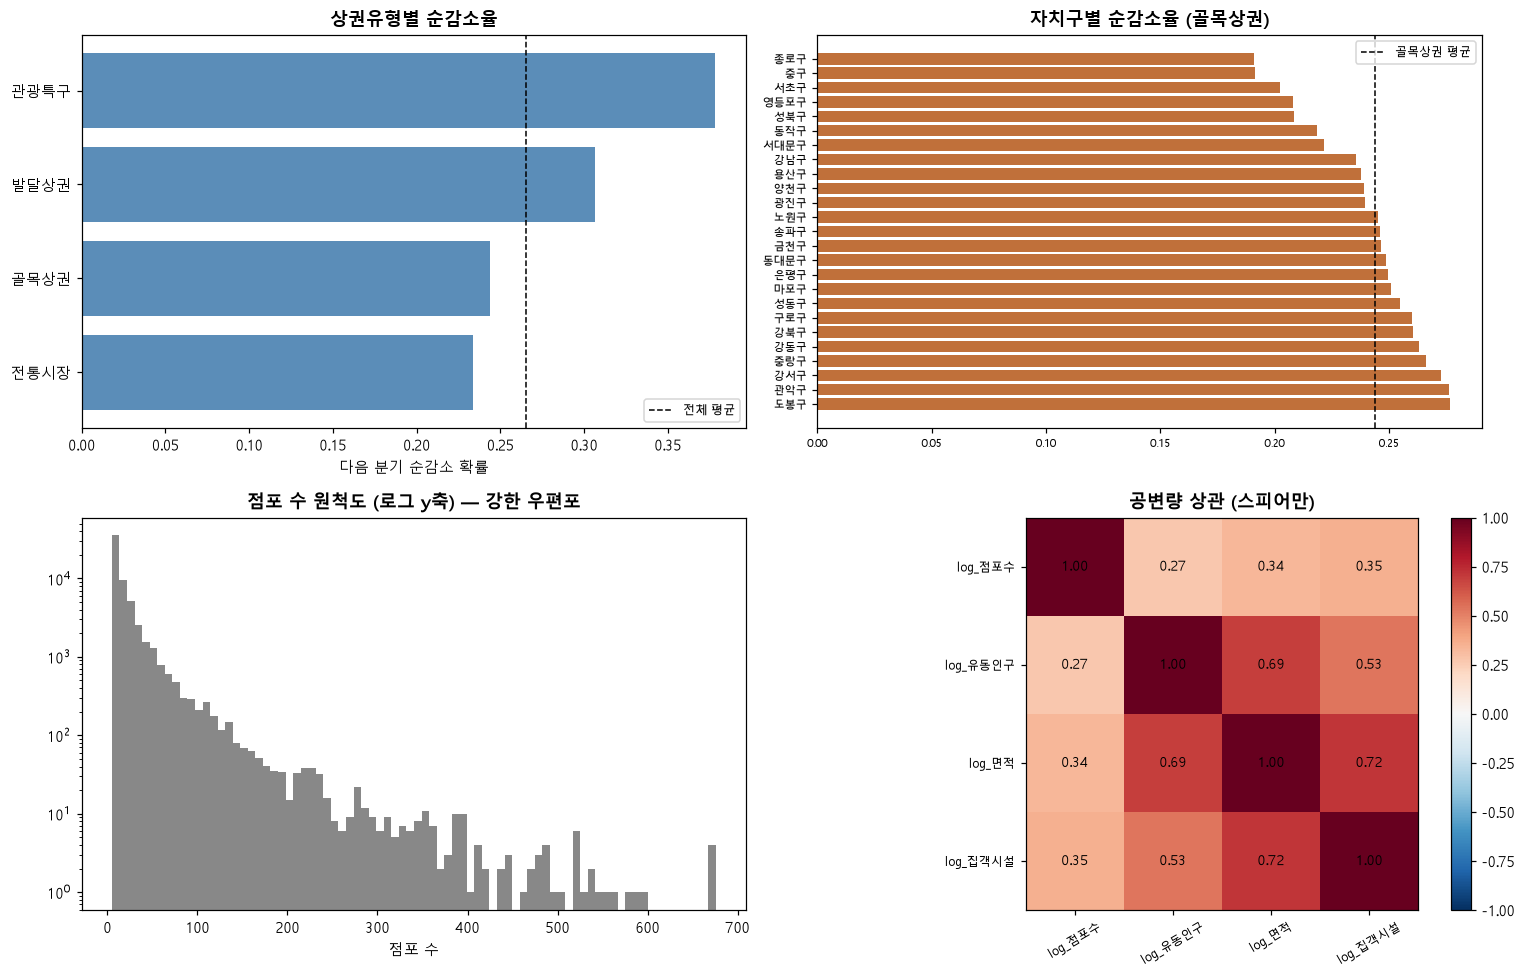

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

t2 = t.sort_values("순감소율")
ax[0,0].barh(t2.index, t2["순감소율"], color="#5b8db8")
ax[0,0].axvline(d["y"].mean(), ls="--", c="k", lw=1, label="전체 평균")
ax[0,0].set_title("상권유형별 순감소율", weight="bold")
ax[0,0].set_xlabel("다음 분기 순감소 확률"); ax[0,0].legend(fontsize=8)

ax[0,1].barh(gu.index, gu["순감소율"], color="#c0703a")
ax[0,1].axvline(gm["y"].mean(), ls="--", c="k", lw=1, label=f"{TARGET_TYPE} 평균")
ax[0,1].set_title(f"자치구별 순감소율 ({TARGET_TYPE})", weight="bold")
ax[0,1].tick_params(labelsize=7); ax[0,1].legend(fontsize=8)

ax[1,0].hist(d["점포_수"], bins=80, color="#888", log=True)
ax[1,0].set_title("점포 수 원척도 (로그 y축) — 강한 우편포", weight="bold")
ax[1,0].set_xlabel("점포 수")

cov = ["log_점포수", "log_유동인구", "log_면적", "log_집객시설"]
corr = d[cov].corr(method="spearman")
im = ax[1,1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1,1].set_xticks(range(len(cov))); ax[1,1].set_xticklabels(cov, rotation=30, fontsize=8)
ax[1,1].set_yticks(range(len(cov))); ax[1,1].set_yticklabels(cov, fontsize=8)
for i in range(len(cov)):
    for j in range(len(cov)):
        ax[1,1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax[1,1].set_title("공변량 상관 (스피어만)", weight="bold")
plt.colorbar(im, ax=ax[1,1], fraction=0.046)

plt.tight_layout()
plt.savefig(FIG / "step4_basic_eda.png", dpi=130)
plt.show()

## 4-5. 다중공선성 점검

In [7]:
display(corr.round(3))
print("※ |r| > 0.8 인 쌍이 있으면 성향점수 모형에서 하나를 빼는 것을 검토하세요.")

,log_점포수,log_유동인구,log_면적,log_집객시설
log_점포수,1.000,0.269,0.336,0.353
log_유동인구,0.269,1.000,0.693,0.533
log_면적,0.336,0.693,1.000,0.717
log_집객시설,0.353,0.533,0.717,1.000


※ |r| > 0.8 인 쌍이 있으면 성향점수 모형에서 하나를 빼는 것을 검토하세요.
